# Exploration — Elevation (Altitude)

Fichiers concernés :
- `data/EnvironmentalValues/Elevation/GLC25-PA-train-elevation.csv`
- `data/EnvironmentalValues/Elevation/GLC25-PA-test-elevation.csv`

Source : ASTER GDEM V3, résolution ~30m (1 arc-seconde). Variable unique : `Elevation` en mètres.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ELEV_DIR = '../data/EnvironmentalValues/Elevation/'

train = pd.read_csv(ELEV_DIR + 'GLC25-PA-train-elevation.csv')
test  = pd.read_csv(ELEV_DIR + 'GLC25-PA-test-elevation.csv')

print('Train shape:', train.shape)
print('Test  shape:', test.shape)
train.head()

Train shape: (88987, 2)
Test  shape: (14829, 2)


,surveyId,Elevation
0,212,47.0
1,222,6.0
2,243,10.0
3,324,116.0
4,333,84.0


## 1. Statistiques de base

In [2]:
print('=== Valeurs manquantes ===')
print('Train:', train.isnull().sum().sum())
print('Test :', test.isnull().sum().sum())

print('\n=== Stats TRAIN ===')
print(train['Elevation'].describe())

print('\n=== Stats TEST ===')
print(test['Elevation'].describe())

=== Valeurs manquantes ===
Train: 35
Test : 0

=== Stats TRAIN ===
count    88952.000000
mean       118.289415
std        287.485892
min          0.000000
25%          9.000000
50%         20.000000
75%         60.000000
max       3256.000000
Name: Elevation, dtype: float64

=== Stats TEST ===
count    14829.000000
mean       419.397667
std        535.500705
min          0.000000
25%         29.000000
50%        155.000000
75%        648.000000
max       2841.000000
Name: Elevation, dtype: float64


## 2. Distribution de l'élévation

/var/folders/28/jsq2jhnj4zz2c_v3q2p5wc580000gn/T/ipykernel_3410/4233725315.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_box, x='split', y='Elevation', ax=axes[1],


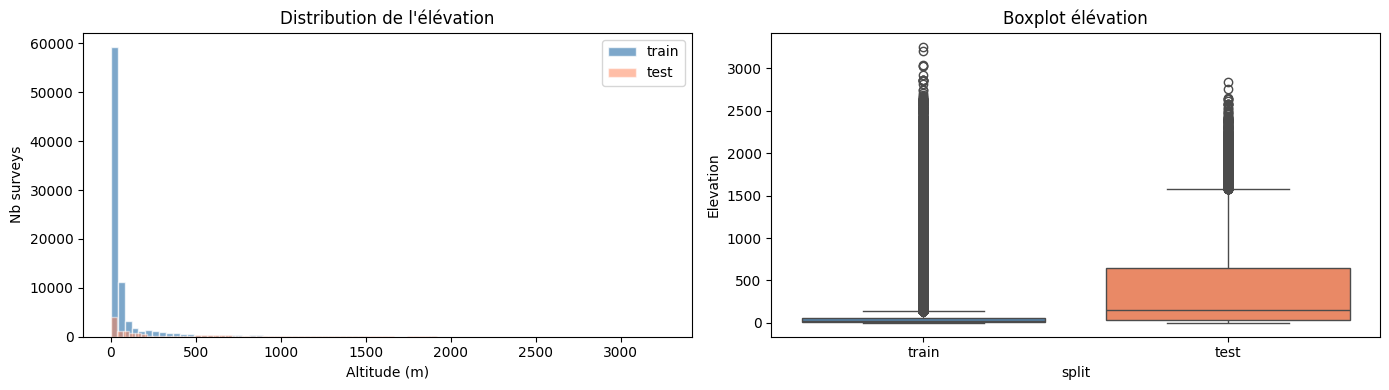

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogramme
axes[0].hist(train['Elevation'].dropna(), bins=80, color='steelblue', alpha=0.7, label='train', edgecolor='white')
axes[0].hist(test['Elevation'].dropna(), bins=80, color='coral', alpha=0.5, label='test', edgecolor='white')
axes[0].set_title('Distribution de l\'élévation')
axes[0].set_xlabel('Altitude (m)')
axes[0].set_ylabel('Nb surveys')
axes[0].legend()

# Boxplot
data_box = pd.DataFrame({
    'Elevation': pd.concat([train['Elevation'], test['Elevation']]).values,
    'split': ['train'] * len(train) + ['test'] * len(test)
})
sns.boxplot(data=data_box, x='split', y='Elevation', ax=axes[1],
            palette={'train': 'steelblue', 'test': 'coral'})
axes[1].set_title('Boxplot élévation')

plt.tight_layout()
plt.show()

## 3. Zones altitudinales

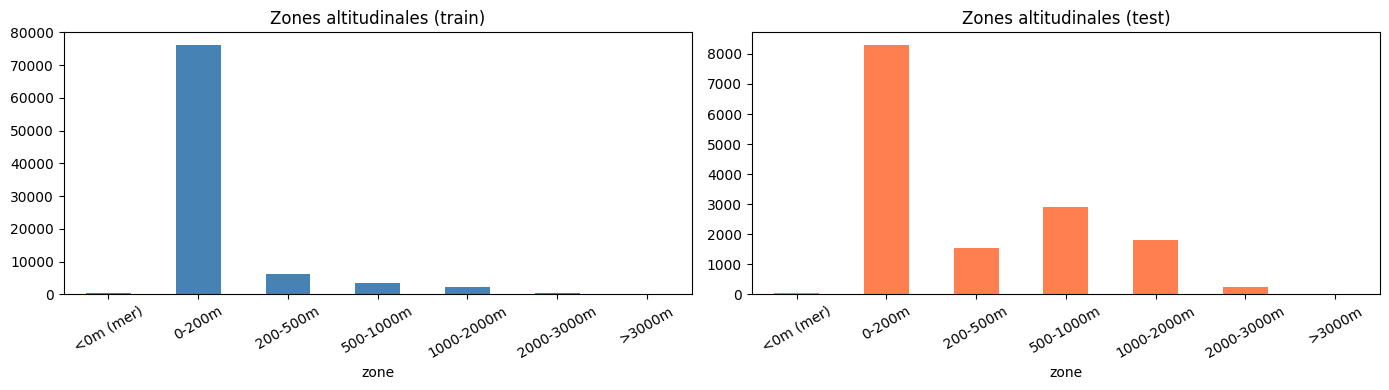

In [4]:
bins = [-500, 0, 200, 500, 1000, 2000, 3000, 5000]
labels = ['<0m (mer)', '0-200m', '200-500m', '500-1000m', '1000-2000m', '2000-3000m', '>3000m']

train['zone'] = pd.cut(train['Elevation'], bins=bins, labels=labels)
test['zone']  = pd.cut(test['Elevation'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
train['zone'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Zones altitudinales (train)')
axes[0].tick_params(axis='x', rotation=30)

test['zone'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Zones altitudinales (test)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 4. Élévation vs géolocalisation

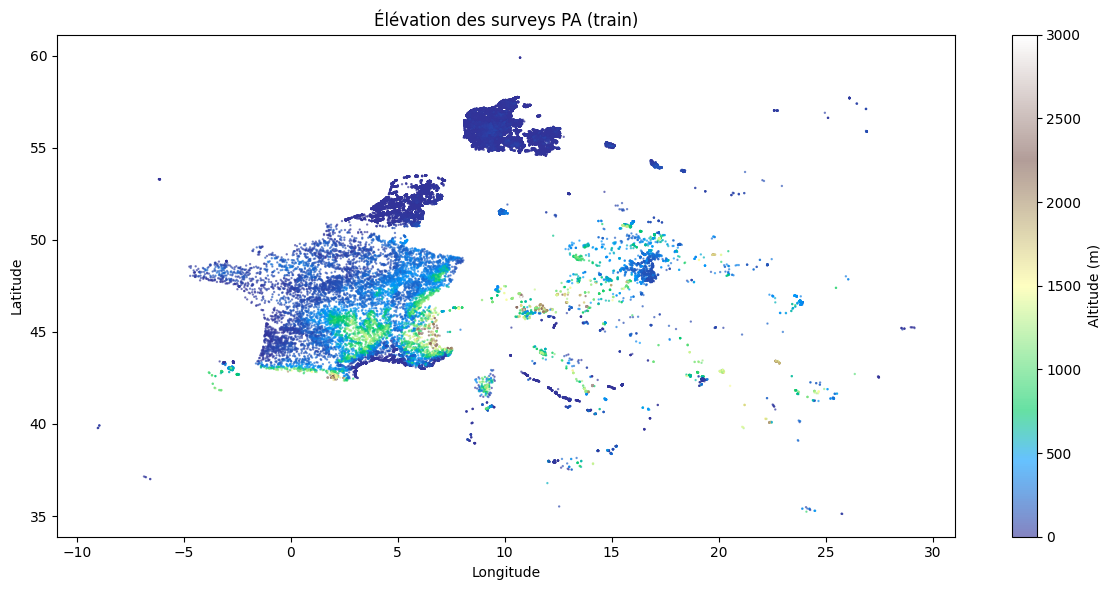

In [5]:
meta = pd.read_csv('../data/GLC25_PA_metadata_train.csv').drop_duplicates('surveyId')[['surveyId', 'lon', 'lat']]
merged = train.merge(meta, on='surveyId')

fig, ax = plt.subplots(figsize=(12, 6))
sc = ax.scatter(merged['lon'], merged['lat'], c=merged['Elevation'], cmap='terrain',
                s=0.5, alpha=0.6, vmin=0, vmax=3000)
plt.colorbar(sc, ax=ax, label='Altitude (m)')
ax.set_title('Élévation des surveys PA (train)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()